<img src="https://i.ibb.co/93sNcdhp/Logo-pmat-color.png" align="right" width="150">

<br>

# **Modelo de Regresión Lineal Múltiple**

### **Objetivos de Aprendizaje**

Al finalizar este laboratorio, serás capaz de:

* Construir modelos de regresión lineal múltiple con Python en contextos aplicados.
* Interpretar los coeficientes, la significancia y la calidad del ajuste de un modelo de regresión lineal múltiple.
* Realizar estimaciones a partir de un modelo ajustado, interpretando los resultados en contexto.
* Comparar modelos completos y reducidos para justificar la selección de un modelo adecuado.


In [1]:
# @title
%%html
<div style="border: 4px solid #006d77; border-radius: 0px; overflow: hidden; font-family: sans-serif; max-width: 800px; margin-bottom: 20px;">

  <div style="background-color: #000000; color: #ffc107; padding: 10px 15px; font-weight: bold; font-size: 16px; display: flex; align-items: center;">
    <span style="margin-right: 10px; font-size: 18px;">💡</span>
    <span>Regresión lineal múltiple</span>
  </div>

  <div style="background-color: #ffffff; padding: 20px; display: flex; align-items: center; justify-content: space-between;">

    <div style="color: #000000; flex: 1; padding-right: 30px; font-size: 14px; line-height: 1.5;">
      ¿Cómo podemos saber qué variables aportan realmente a una predicción?
      <br>
      En el análisis de datos, muchas decisiones requieren estudiar cómo varios
      factores se relacionan simultáneamente con una variable de interés.
      <b>Escanea o haz clic sobre el código QR</b> para revisar cómo la regresión lineal múltiple
      permite interpretar el aporte de distintos predictores, evaluar la calidad del modelo y apoyar decisiones basadas en evidencia.
      </div>

    <div style="flex-shrink: 0;">
      <a href="https://duoc.h5p.com/content/1292748477585768438" target="_blank">
        <img src="https://i.ibb.co/nNWJRxTJ/MRmultiple.png"
             alt="QR Code"
             style="width: 100px; height: 100px; border: none;">
      </a>
    </div>

  </div>

  <div style="background-color: #000000; color: #ffc107; padding: 8px 15px; font-weight: bold; font-size: 16px;">
    Presentación interactiva H5P
  </div>

</div>


### **Recordatorio Clave**

El modelo de Regresión Lineal Múltiple (RLM) permite analizar la relación entre una variable dependiente Y y dos o más variables predictoras $X_1$, $X_2$,…,$X_k$. A diferencia de la regresión lineal simple, este modelo incorpora simultáneamente varios factores que podrían ayudar a explicar o estimar una variable de interés.
El modelo se expresa como:

<br>

$$Y=β_0+β_1 X_1+β_2 X_2+⋯+β_k X_k+ε$$

donde:
* $Y$: variable dependiente o variable que se desea explicar o estimar.
* $X_1,X_2,…,X_k$: variables predictoras incluidas en el modelo.
* $β_0$: intercepto del modelo.
* $β_1,β_2,…,β_k$: coeficientes asociados a cada variable predictora.
* $ε$: término de error, que representa la parte de Y que no es explicada por las variables predictoras.

Cada coeficiente $β_j$ representa el cambio promedio esperado en $Y$ cuando la variable $X_j$ aumenta en una unidad, manteniendo constantes las demás variables predictoras.


### **Indicadores Principales**

| Indicador | Significado                                                                              |
| ----------- | ------------------------------------------------------------------------------------------- |
| $R^2$       | Indica la proporción de la variabilidad de Y que es explicada por el modelo.|
| $R^2_{aj}$  | Indica el ajuste del modelo considerando la cantidad de variables predictoras incluidas.|
| $F$         | Evalúa si el modelo en conjunto es estadísticamente significativo.|
| $p$-valor de cada predictor| Permite decidir si cada variable predictora aporta significativamente al modelo, considerando las demás variables incluidas.|


# **Actividad 1 - Evaluación del modelo de ventas**

El equipo de análisis comercial de una empresa desea evaluar si las ventas mensuales, medidas en miles de unidades, pueden explicarse a partir de dos factores: la inversión en publicidad, medida en miles de USD, y la cantidad de vendedores activos durante el mes, medida en unidades.

Durante los últimos diez meses se registraron los siguientes datos:


| Mes | Publicidad (miles USD) | Vendedores | Ventas (miles de unidades) |
| --- | ---------------------: | ---------: | -------------------------: |
| 1   |                      5 |          3 |                         40 |
| 2   |                      7 |          4 |                         46 |
| 3   |                      9 |          4 |                         52 |
| 4   |                     10 |          5 |                         55 |
| 5   |                     12 |          5 |                         61 |
| 6   |                     13 |          6 |                         66 |
| 7   |                     15 |          6 |                         70 |
| 8   |                     17 |          7 |                         77 |
| 9   |                     18 |          7 |                         78 |
| 10  |                     20 |          8 |                         84 |


La gerencia sospecha que el incremento simultáneo en publicidad y personal de ventas podría explicar gran parte del aumento en las ventas, pero desea cuantificar la influencia de cada factor y verificar si ambos son estadísticamente significativos.

1. Identifique la variable dependiente y las variables predictoras que se utilizarán en el modelo de regresión lineal múltiple.

2. Utilice Python para ajustar el modelo de regresión lineal múltiple y visualizar la tabla de resultados OLS.

3. A partir de la tabla OLS, identifique el valor del estadístico F, ¿qué representa este estadístico en un modelo de regresión múltiple?

4. Compare el $p$-valor asociado al estadístico $F$ con un nivel de significancia del 5%, ¿qué conclusión se obtiene sobre la significancia global del modelo?

5. ¿Qué implicaría un $p$-valor mayor a 0,05 para el modelo comercial de ventas?

# **Actividad 2 – Comprendiendo el modelo múltiple**

A partir del modelo de regresión lineal múltiple ajustado en la actividad anterior, se analizarán ahora sus componentes principales: la ecuación estimada, la calidad del ajuste y el aporte individual de cada variable predictora. Este análisis permitirá interpretar los resultados del modelo y formular una recomendación preliminar para la gerencia.

1. Escriba la ecuación del modelo estimado, indicando el intercepto y los coeficientes $\beta_{1}$ y $\beta_{2}$

2. Interprete el significado de los coeficientes de *publicidad* y *vendedores* en el contexto del negocio.

3. Analice los valores de $R^2$ y $R^2_{aj}$ e indique qué representan sobre la variabilidad explicada por el modelo.

4. Verifique los valores $p$ asociados a cada predictor, e indique si ambas variables resultan significativas con un nivel de significancia del 5%.

5. A partir de los coeficientes estimados y los p-valores, ¿qué variable parece aportar más información al modelo? ¿Qué recomendación preliminar podría entregar el analista a la gerencia?

# **Actividad 3 - Predicción en contexto empresarial**

A partir del modelo de regresión lineal múltiple ajustado en la actividad anterior, la gerencia desea estimar las ventas mensuales esperadas si la empresa invierte 14 mil USD en publicidad y mantiene 6 vendedores activos durante el mes.

1. ¿Cuál es la predicción de ventas esperadas con los valores indicados?

2.	Interprete la predicción obtenida en el contexto del problema.

3.	Si la empresa mantuviera 6 vendedores activos, pero aumentara la inversión en publicidad de 14 a 16 mil USD, ¿cómo cambiaría la predicción de ventas según el modelo? Interprete el resultado en el contexto del problema.

4.	Compare los valores utilizados para realizar las predicciones con los datos originales. ¿La estimación se realiza para un escenario similar a los observados por la empresa? Justifique.


# **Actividad 4 - Camiones con motores diesel**

Un grupo de ingenieros ambientales realizó un estudio para evaluar cómo las condiciones atmosféricas se relacionan con las emisiones de óxidos de nitrógeno ($NO_{x}$) generadas por camiones livianos que utilizan motor diésel. Para ello, se realizaron mediciones en distintas condiciones atmosféricas registrando las siguientes variables:

* Humedad del aire ($\%$)
* Temperatura ambiente ($°F$)
* Presión barométrica ($inHg$)
* Concentración de $NO_x$ emitida ($ppm$)

A partir de estos datos, se desea estudiar cómo las condiciones atmosféricas se relacionan con las emisiones registradas.

Los datos experimentales se encuentran disponibles **<a href="https://docs.google.com/spreadsheets/d/1qlmoa374nalX7QAcV6SI4G3AWNuoykJ8/export?format=xlsx">aquí</a>**.

1. Identifique la variable dependiente y las variables predictoras que se utilizarán en el modelo de regresión lineal múltiple.

2. Escriba la ecuación del modelo estimado.

3. Evalúe la significancia global del modelo con un nivel de significancia del 5%. Indique qué valor de la tabla OLS debe utilizar y justifique su conclusión.

4. Interprete los coeficientes del modelo en el contexto del problema.

5. ¿Qué variables resultan significativas? ¿Qué significa este resultado en el contexto del problema?

6. Compare los valores de $R^2$ y $R_{aj}^2$. ¿El ajuste del modelo se mantiene alto después de considerar la cantidad de variables predictoras incluidas? Justifique en el contexto del problema.

7. Según el modelo obtenido, ¿qué variable atmosférica debería considerarse con mayor atención al evaluar las emisiones de óxidos de nitrógeno?

8. Para 50% de humedad, una temperatura de 76°F y una presión barométrica de 29,30 inHg, , ¿cuál es la concentración estimada de $NO_x$ emitida?

# **Actividad 5 - Consumo de energía**

Una planta industrial desea analizar su consumo mensual de energía eléctrica, medido en megavatios hora (MWh). Para ello, se recopilaron registros históricos asociados a distintas condiciones de operación: temperatura ambiental promedio, medida en grados Fahrenheit; cantidad de días de operación de la planta durante el mes, medida en días; pureza promedio del producto, medida en porcentaje; y producción mensual, medida en toneladas.

A partir de estos **<a href="https://drive.google.com/uc?export=download&id=10KfI815rJmKgIGnQg_H1NthLU3_FAcgd"> datos</a>** se desea estudiar cómo estas variables se relacionan con el consumo energético registrado.


1. Ajuste un modelo de regresión lineal múltiple para estimar el consumo mensual de energía eléctrica. A partir de los resultados obtenidos, indique si el modelo global resulta significativo al 5%.

2. Identifique qué variables presentan evidencia estadística suficiente para aportar al modelo. Justifique su respuesta considerando los p-valores y el contexto del problema.

3. Proponga un modelo reducido con las variables que mantendría para exlicar el consumo energético.

4. Compare el modelo completo y el modelo reducido usando $R^2$, $R_aj^2$ y significancia de las variables. ¿Cuál recomendaría usar? Justifique su respuesta.

# **Actividad 6 - Análisis de residuos y validación gráfica del modelo de regresión**

En la actividad anterior, la planta industrial comparó un modelo completo y un modelo reducido para analizar el consumo mensual de energía eléctrica. Luego de seleccionar el modelo más conveniente, es importante revisar si sus estimaciones se comportan de manera razonable. Para ello, analice gráficamente el consumo real y los valores estimados por el modelo seleccionado.

Siga los pasos indicados a continuación para calcular los residuos, construir los gráficos e interpretar el comportamiento del modelo.

1. Genere una columna con los valores estimados por el modelo seleccionado y otra con los residuos.

**Nota:** recuerde que los residuos corresponden a la diferencia entre el consumo real y el consumo estimado.


2. Construya un gráfico de consumo real versus consumo estimado. ¿Qué se observa respecto a la cercanía entre los valores reales y los valores estimados?

3. Construya un gráfico de residuos versus consumo estimado. ¿Los residuos parecen distribuirse alrededor de cero sin un patrón evidente? Justifique brevemente.

4. A partir de los gráficos, ¿considera que el modelo seleccionado entrega estimaciones razonables del consumo energético? Fundamente su respuesta

# **Actividad 7 - Rendimiento académico**

Un investigador universitario busca analizar si el rendimiento académico final de los estudiantes se relaciona con distintas variables asociadas a su desempeño durante el semestre: horas de estudio semanal, porcentaje de asistencia a clases, promedio de notas parciales y promedio de notas de cuestionarios.

Se dispone de un set de datos con registros de estudiantes de una misma asignatura. A partir de estos datos, se desea estudiar qué variables aportan más información para explicar la nota final.

Descargue el set de datos **<a href="https://drive.google.com/uc?export=download&id=17J95AvgnkvF9yTGCEqtdPaUDrezMnwZs">aquí</a>**.


1. Ajuste un modelo de regresión lineal múltiple para estimar la nota final de los estudiantes a partir de las variables disponibles. Escriba la ecuación del modelo estimado.

2. Evalúe si el modelo global resulta significativo con un nivel de significancia del 5%. Justifique su respuesta.

3. Identifique qué variables presentan evidencia estadística suficiente para aportar al modelo. Justifique su respuesta.

4. Compare los valores de $R^2$  y $R_{aj}^2$. ¿Qué indican sobre la calidad del modelo construido?

5. Proponga un modelo reducido con las variables que mantendría para explicar la nota final. Ajuste este nuevo modelo y justifique su elección.

6. Compare el modelo completo y el modelo reducido considerando $R^2$,$R_aj^2$ y la simplicidad del modelo. ¿Cuál recomendaría utilizar para analizar la nota final? Justifique su respuesta.

7. Mencione una precaución que debería considerarse antes de usar este modelo para analizar el rendimiento académico de otros grupos de estudiantes.

# **Actividad 8 - Comunicación de resultados de un modelo de regresión múltiple**

Un equipo de soporte técnico de una empresa de servicios digitales desea analizar qué factores se relacionan con el tiempo que tarda en resolverse un ticket de atención. Para ello, se ajustó un modelo de regresión lineal múltiple considerando registros históricos de tickets atendidos durante los últimos meses.

La variable dependiente es el tiempo de resolución del ticket, medido en horas. Las variables predictoras consideradas fueron:

*	`tickets_asignados`: cantidad de tickets asignados al técnico durante el día.
*	`complejidad`: nivel de complejidad del ticket, medido en una escala de 1 a 5.
*	`experiencia`: experiencia del técnico, medida en meses.
*	`consultas_base`: cantidad de consultas realizadas a la base de conocimiento interna.

A continuación, se presenta una tabla resumida con los resultados del modelo OLS:


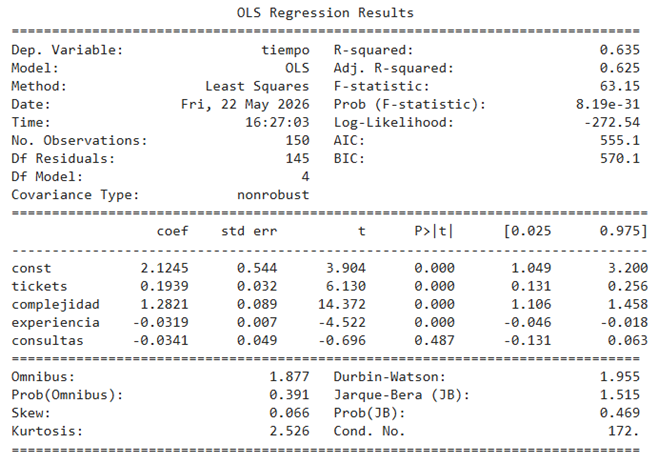

1. Identifique qué información del modelo sería más importante comunicar a un equipo de soporte no especializado en estadística.

2. Redacte una conclusión breve sobre qué variables parecen aportar más información para explicar el tiempo de resolución de los tickets.

3. Explique una decisión operativa que podría apoyarse en estos resultados y una decisión que no sería prudente tomar solo con este modelo.

4. Mencione una limitación del modelo y proponga qué información adicional sería útil recopilar para mejorar el análisis.

# Reflexión

* En regresión lineal múltiple, no basta con construir el modelo: también es necesario interpretar sus resultados en el contexto del problema.
* La elección entre un modelo completo y uno reducido debe justificarse considerando el ajuste, la cantidad de variables, la significancia de los predictores y la interpretación contextual. Un modelo más simple puede ser conveniente solo si no pierde capacidad explicativa relevante.
* La significancia global del modelo y la significancia individual de los predictores responden preguntas distintas.
* Los valores de $R^2$ y $R_aj^2$ deben analizarse junto con los $p$-valores, los gráficos y el contexto del problema.
* Las predicciones y recomendaciones deben formularse con cautela, ya que el modelo muestra asociaciones y no necesariamente relaciones causales.


# Con este laboratorio aprendiste a:

*	Reconocer la estructura de un modelo de regresión lineal múltiple (intercepto, coeficientes y variables predictoras).
*	Construir modelos de regresión lineal múltiple utilizando Python como herramienta de cálculo.
*	Interpretar coeficientes en contexto, entendiendo qué significa “mantener constantes las demás variables”.
*	Usar e interpretar indicadores clave del modelo:  $R^2$ y $R^2_{aj}$, $p$-valores y estadístico $F$.
*	Evaluar la significancia de cada predictor y decidir cuáles variables aportan realmente al modelo.
*	Comparar modelos completos y reducidos, justificando cuál es más adecuado según simplicidad y capacidad explicativa.
*	Aplicar el modelo para hacer predicciones en contextos reales (ventas, emisiones, consumo de energía, rendimiento académico) y reflexionar sobre sus limitaciones (tamaño muestral, supuestos, generalización).
